# Dimensionality Reduction Comparison

In this notebook we compare several dimensionality reduction techniques:

• Principal Component Analysis (PCA)  
• Kernel PCA  
• Isomap  
• t-SNE  

We evaluate how each method behaves on nonlinear data (Swiss Roll).

Goal:

Understand how different algorithms preserve structure in low-dimensional embeddings.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import Isomap, TSNE

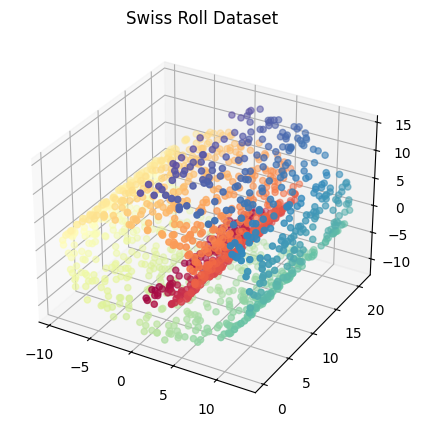

In [2]:
X, t = make_swiss_roll(n_samples=1500, noise=0.1, random_state=42)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], c=t, cmap="Spectral")
ax.set_title("Swiss Roll Dataset")
plt.show()

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [5]:
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.001)
X_kpca = kpca.fit_transform(X)

In [6]:
isomap = Isomap(n_neighbors=10, n_components=2)
X_isomap = isomap.fit_transform(X)

In [7]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

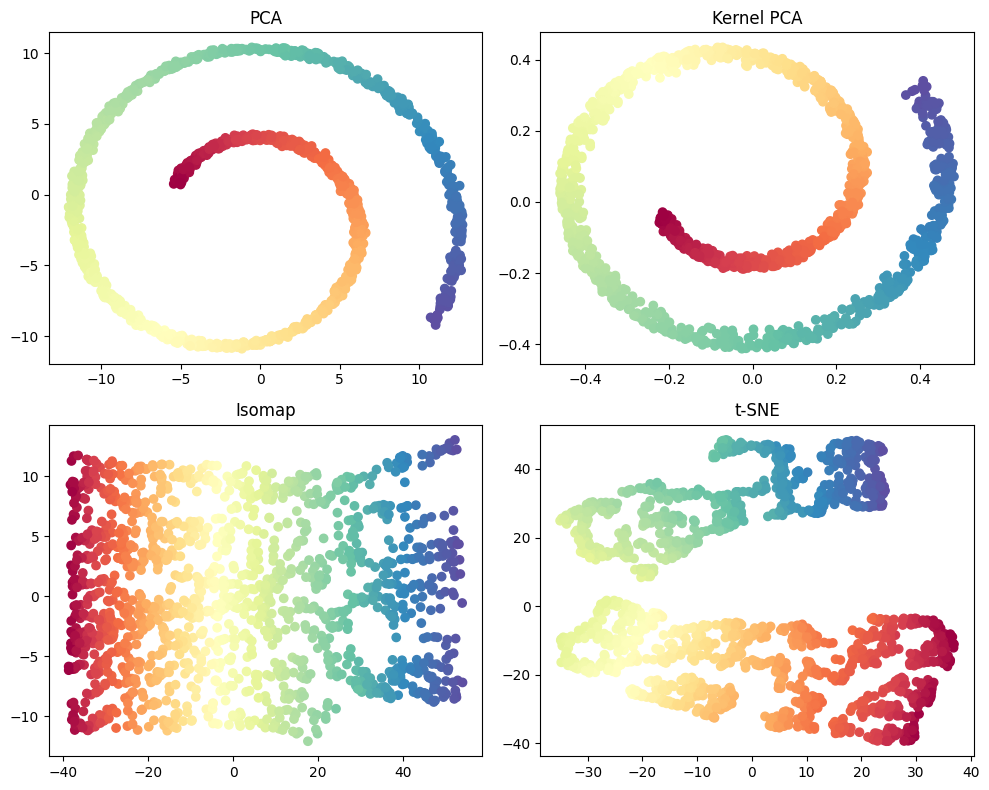

In [10]:
fig, axes = plt.subplots(2,2, figsize=(10,8))

axes[0,0].scatter(X_pca[:,0], X_pca[:,1], c=t, cmap="Spectral")
axes[0,0].set_title("PCA")

axes[0,1].scatter(X_kpca[:,0], X_kpca[:,1], c=t, cmap="Spectral")
axes[0,1].set_title("Kernel PCA")

axes[1,0].scatter(X_isomap[:,0], X_isomap[:,1], c=t, cmap="Spectral")
axes[1,0].set_title("Isomap")

axes[1,1].scatter(X_tsne[:,0], X_tsne[:,1], c=t, cmap="Spectral")
axes[1,1].set_title("t-SNE")

plt.tight_layout()
plt.show()

## Interpretation of Results

PCA:
* Linear projection  
* Fails to unfold nonlinear structure  
* Overlapping layers remain

Kernel PCA:
* Captures nonlinear similarity
* Partial manifold unfolding
* Sensitive to kernel parameters

Isomap:
* Preserves geodesic distances
* Successfully unwraps Swiss Roll
* Effective manifold learning method

t-SNE:
* Preserves local neighborhoods
* Excellent for visualization
* Global distances are distorted

| Method | Preserves | Strength | Weakness |
|------|------|------|------|
| PCA | Global variance | Fast & stable | Cannot capture nonlinear manifolds |
| Kernel PCA | Nonlinear similarity | Flexible mapping | Expensive (n² memory) |
| Isomap | Geodesic distances | Good manifold recovery | Sensitive to neighborhood size |
| t-SNE | Local neighborhoods | Excellent visualization | Poor global structure |